In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL.GimpGradientFile import linear
from sklearn.datasets import make_moons

In [2]:
x,y = make_moons(n_samples=1000,noise=0.2)

In [3]:
df = {"x1":x[:,0],"x2":x[:,1],"y":y}

In [4]:
dataset = pd.DataFrame(df)

In [5]:
dataset

,x1,x2,y
0,1.571042,0.203560,0
1,0.765039,0.079972,0
2,1.153012,-0.256953,1
3,0.594822,0.739780,0
4,0.282011,0.947623,0
...,...,...,...
995,-0.136968,0.459462,1
996,0.375776,-0.017830,1
997,1.751541,-0.286019,1
998,1.454021,-0.405392,1


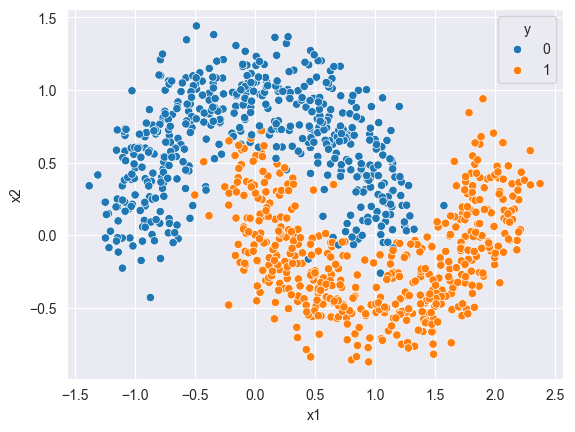

In [6]:
sns.scatterplot(x = "x1", y = "x2", data = dataset, hue = "y")
plt.show()

In [7]:
x_a = dataset.iloc[:,:-1]
y_a = dataset["y"]

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
x_train,x_test,y_train,y_test = train_test_split(x_a,y_a,test_size=0.2,random_state=42)

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [11]:
dt = DecisionTreeClassifier()
dt.fit(x_train,y_train)
dt.score(x_train,y_train)*100, dt.score(x_test, y_test)*100

(100.0, 96.0)

In [15]:
sv = SVC()
sv.fit(x_train,y_train)
sv.score(x_train,y_train)*100, sv.score(x_test, y_test)*100

(97.875, 97.5)

In [16]:
ga = GaussianNB()
ga.fit(x_train,y_train)
ga.score(x_train,y_train)*100, ga.score(x_test, y_test)*100

(86.5, 91.0)

In [18]:
from sklearn.ensemble import VotingClassifier

In [19]:
li = [("dt1",DecisionTreeClassifier()),("SV1", SVC()),("Ga",GaussianNB())]

In [24]:
vc = VotingClassifier(li)
vc.fit(x_train,y_train)
vc.score(x_train,y_train)*100,vc.score(x_train,y_train)*100

(97.875, 97.875)

In [28]:
prd = {"dt": dt.predict(x_test),"svm":sv.predict(x_test),"gnb":ga.predict(x_test),"vc":vc.predict(x_test)}

In [29]:
pd.DataFrame(prd)

,dt,svm,gnb,vc
0,1,1,1,1
1,0,0,0,0
2,0,0,0,0
3,0,0,0,0
4,0,0,0,0
...,...,...,...,...
195,1,1,1,1
196,1,1,1,1
197,1,1,1,1
198,0,0,0,0
